# 18 · Structured-pruning comparison and handoff

**Goal:** compare block and dependency-aware channel pruning using offline quality, exact graph resources, and physical ESP32 measurements. This notebook does not train or silently promote a model.

## Decision model

A candidate survives only if it lies on the measured Pareto frontier: no other candidate may be at least as accurate, faster, and smaller in arena/Flash simultaneously. Analytical MACs are a screening coordinate; ESP32 Invoke time is the speed source of truth.

In [1]:
import json
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

from vww_esp32.config import find_project_root, load_config
from vww_esp32.modeling import build_tiny_mobilenet_v1
from vww_esp32.profiling import profile_model
from vww_esp32.pruning import NAMED_CHANNEL_SCHEDULES, block_pruning_specs

ROOT = find_project_root(); config, _ = load_config('configs/pruning.yaml')
OUT = ROOT / 'artifacts/pruning/comparison'; (OUT / 'figures').mkdir(parents=True, exist_ok=True); (OUT / 'reports').mkdir(parents=True, exist_ok=True)
sns.set_theme(style='whitegrid', context='notebook')

## 1 · Pre-registered structural frontier

This table is reproducible before training and proves whether each candidate is physically smaller. It prevents accuracy-only selection from hiding unchanged compute.

,candidate,technique,parameters,macs,peak_live_int8,removed_blocks,schedule,mac_reduction_pct,parameter_reduction_pct
0,ema_qat_parent,parent,111793,3993536,51200,,8-16-32-32-64-64-128-128-128-128-256,0.000000,0.000000
1,remove_block7,block,93233,3555136,51200,block7,8-16-32-32-64-64-128-128-128-128-256,10.977740,16.602113
2,remove_block8,block,93233,3555136,51200,block8,8-16-32-32-64-64-128-128-128-128-256,10.977740,16.602113
3,remove_block9,block,93233,3555136,51200,block9,8-16-32-32-64-64-128-128-128-128-256,10.977740,16.602113
4,moderate_a,channel,74801,2824320,51200,,8-16-24-24-48-48-104-104-104-104-208,29.277713,33.089728
5,moderate_b,channel,69081,2901056,51200,,8-16-24-32-48-64-96-96-96-96-192,27.356208,38.206328
6,aggressive,channel,48985,2301840,51200,,8-16-24-24-40-48-80-80-80-80-160,42.360855,56.182409


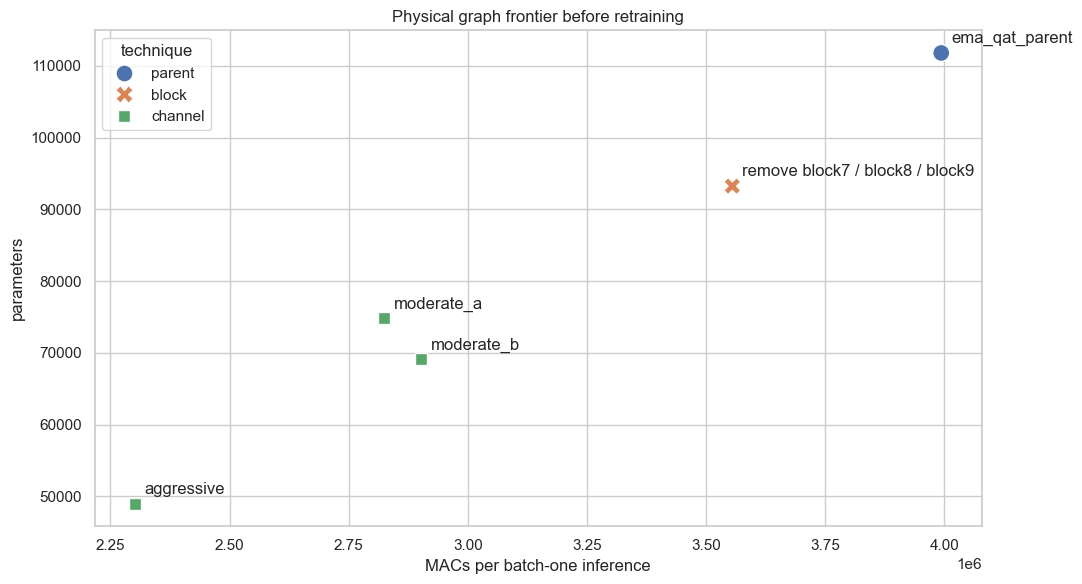

In [2]:
rows = []
definitions = [('ema_qat_parent', tuple(config['model']['reference_channels']), ())]
definitions += [(spec.name, spec.channel_schedule, spec.removed_blocks) for spec in block_pruning_specs()]
definitions += [(name, schedule, ()) for name, schedule in NAMED_CHANNEL_SCHEDULES.items() if name != 'reference']
for name, schedule, removed in definitions:
    model = build_tiny_mobilenet_v1(input_shape=(80, 80, 3), channel_schedule=schedule, removed_blocks=removed)
    _, _, profile = profile_model(model)
    rows.append({'candidate': name, 'technique': 'parent' if name == 'ema_qat_parent' else ('block' if removed else 'channel'), 'parameters': profile['parameters'], 'macs': profile['estimated_macs_batch1'], 'peak_live_int8': profile['peak_live_activation_int8_bytes_batch1_hypothetical'], 'removed_blocks': ','.join(removed), 'schedule': '-'.join(map(str, schedule))})
structural = pd.DataFrame(rows); baseline = structural.iloc[0]
structural['mac_reduction_pct'] = 100 * (1 - structural.macs / baseline.macs); structural['parameter_reduction_pct'] = 100 * (1 - structural.parameters / baseline.parameters)
structural.to_csv(OUT / 'reports/pre_registered_structural_frontier.csv', index=False)
display(structural)
fig, ax = plt.subplots(figsize=(11, 6))
sns.scatterplot(data=structural, x='macs', y='parameters', hue='technique', style='technique', s=150, ax=ax)
labelled_block_point = False
for row in structural.itertuples():
    if row.technique == 'block':
        if labelled_block_point: continue
        label, labelled_block_point = 'remove block7 / block8 / block9', True
    else: label = row.candidate
    ax.annotate(label, (row.macs, row.parameters), xytext=(7, 7), textcoords='offset points')
ax.set(title='Physical graph frontier before retraining', xlabel='MACs per batch-one inference', ylabel='parameters')
fig.tight_layout(); fig.savefig(OUT / 'figures/structural_frontier.png', dpi=170, bbox_inches='tight'); plt.show()

## 2 · Import completed offline experiments

Notebook 16 and 17 write immutable summaries. Missing runs remain visible instead of being filled with estimates.

,technique,track,candidate,accuracy,precision,recall,specificity,f1,pr_auc,macs,peak_live_int8,model_bytes,diagnostic_pass,promotion_pass
0,parent,control,ema_qat_parent,0.7020,0.656377,0.823649,0.584887,0.730561,0.790882,3993536,51200,167976,True,True
1,block,selected,remove_block9,0.6680,0.614275,0.868502,0.474975,0.719595,0.780714,3555136,51200,142640,True,True
2,channel,quality,moderate_b,0.6660,0.612186,0.870540,0.469087,0.718855,0.780966,2901056,51200,117040,True,False
3,channel,deployment,aggressive,0.6605,0.607244,0.871560,0.457311,0.715781,0.774510,2301840,51200,91568,True,True


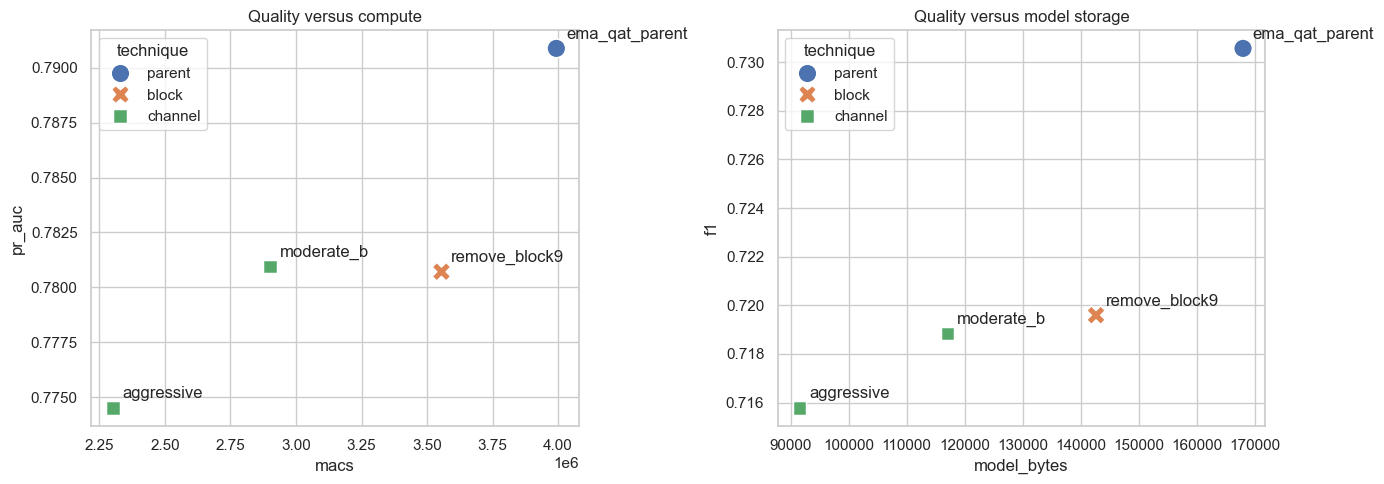

In [3]:
summary_paths = {'block': ROOT / 'artifacts/pruning/block/reports/experiment_summary.json', 'channel': ROOT / 'artifacts/pruning/channel/reports/experiment_summary.json'}
parent_metrics = json.loads((ROOT / config['reference']['int8_metrics']).read_text())
parent_profile = json.loads((ROOT / config['reference']['model_profile']).read_text())
offline_rows = [{'technique': 'parent', 'track': 'control', 'candidate': 'ema_qat_parent', 'accuracy': parent_metrics['accuracy'], 'precision': parent_metrics['precision'], 'recall': parent_metrics['recall'], 'specificity': parent_metrics['specificity'], 'f1': parent_metrics['f1'], 'pr_auc': parent_metrics['pr_auc'], 'macs': parent_profile['estimated_macs_batch1'], 'peak_live_int8': parent_profile['peak_live_activation_int8_bytes_batch1_hypothetical'], 'model_bytes': parent_profile['tflite_bytes'], 'diagnostic_pass': True, 'promotion_pass': True}]
for technique, path in summary_paths.items():
    if not path.is_file(): continue
    payload = json.loads(path.read_text())
    records = list(payload.get('candidates', {}).items()) if technique == 'channel' and payload.get('candidates') else [('selected', payload)]
    for track, record in records:
        metrics, profile = record['int8_test_metrics'], record['model_profile']
        offline_rows.append({'technique': technique, 'track': track, 'candidate': record['selected_candidate'], 'accuracy': metrics['accuracy'], 'precision': metrics['precision'], 'recall': metrics['recall'], 'specificity': metrics['specificity'], 'f1': metrics['f1'], 'pr_auc': metrics['pr_auc'], 'macs': profile['estimated_macs_batch1'], 'peak_live_int8': profile['peak_live_activation_int8_bytes_batch1_hypothetical'], 'model_bytes': record['export']['size_bytes'], 'diagnostic_pass': record.get('ready_for_diagnostic_profile', record['ready_for_device_profile']), 'promotion_pass': record['ready_for_device_profile']})
offline = pd.DataFrame(offline_rows)
if len(offline):
    offline.to_csv(OUT / 'reports/offline_comparison.csv', index=False); display(offline)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5)); sns.scatterplot(data=offline, x='macs', y='pr_auc', hue='technique', style='technique', s=180, ax=axes[0]); sns.scatterplot(data=offline, x='model_bytes', y='f1', hue='technique', style='technique', s=180, ax=axes[1]); axes[0].set_title('Quality versus compute'); axes[1].set_title('Quality versus model storage');
    for row in offline.itertuples():
        axes[0].annotate(row.candidate, (row.macs, row.pr_auc), xytext=(7, 7), textcoords='offset points')
        axes[1].annotate(row.candidate, (row.model_bytes, row.f1), xytext=(7, 7), textcoords='offset points')
    fig.tight_layout(); fig.savefig(OUT / 'figures/offline_frontier.png', dpi=170, bbox_inches='tight'); plt.show()
else: display(Markdown('**Offline pruning runs pending.** Execute notebooks 16 and 17 first.'))

## 3 · Import physical ESP32 profiles

Only real-device profiles may support a latency or arena claim. Each profile uses batch one, the same toolchain, two warm-ups, and 20 measured invokes for screening; finalists require the longer stability run defined in the pruning plan.

,candidate,invoke_ms,model_only_fps,pipeline_fps,arena_used_bytes,model_bytes,macs,latency_change_pct,arena_change_pct
0,ema_qat_parent,416.9814,2.398189,1.68,69068,167976,3993536,0.000000,0.000000
1,remove_block9,384.5170,2.600665,1.77,66700,142640,3555136,-7.785575,-3.428505


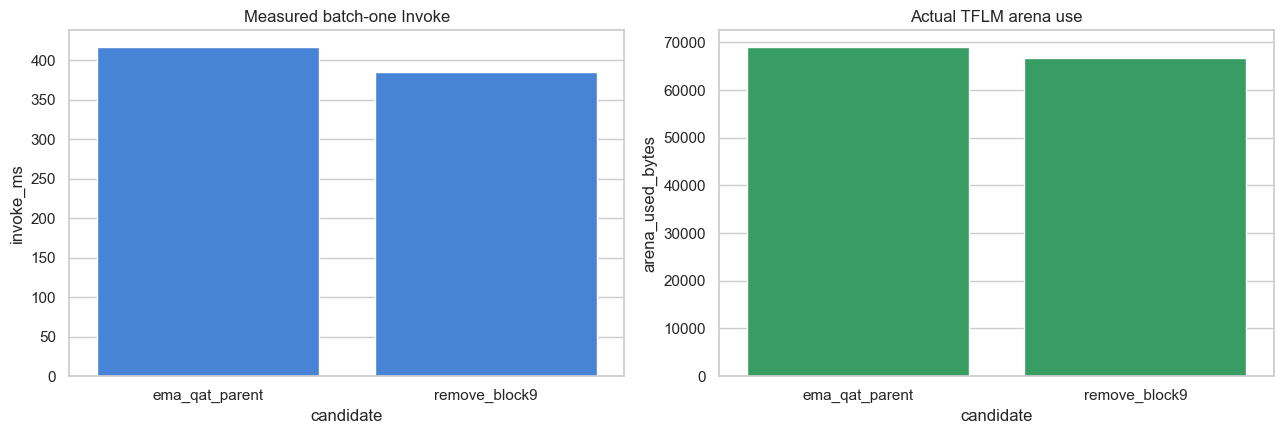

In [4]:
profile_ids = {'ema_qat_parent': 'qat_ema_range', 'remove_block9': 'prune_block_selected', 'moderate_b': 'prune_channel_moderate_b', 'aggressive': 'prune_channel_aggressive'}
device_rows = []
for label, profile_id in profile_ids.items():
    path = ROOT / 'artifacts/device_profiles' / profile_id / 'device_profile_summary.json'
    if not path.is_file(): continue
    payload = json.loads(path.read_text()); mean_ms = payload.get('mean_us', 0) / 1000
    device_rows.append({'candidate': label, 'invoke_ms': mean_ms, 'model_only_fps': 1000 / mean_ms, 'pipeline_fps': payload.get('pipeline_fps_median'), 'arena_used_bytes': payload.get('arena_used_bytes'), 'model_bytes': payload.get('model_bytes'), 'macs': payload.get('estimated_macs')})
device = pd.DataFrame(device_rows)
if len(device):
    control = device[device.candidate == 'ema_qat_parent'].iloc[0]; device['latency_change_pct'] = 100 * (device.invoke_ms / control.invoke_ms - 1); device['arena_change_pct'] = 100 * (device.arena_used_bytes / control.arena_used_bytes - 1); device.to_csv(OUT / 'reports/device_comparison.csv', index=False); display(device)
if len(device) > 1:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5)); sns.barplot(data=device, x='candidate', y='invoke_ms', ax=axes[0], color='#2F80ED'); sns.barplot(data=device, x='candidate', y='arena_used_bytes', ax=axes[1], color='#27AE60'); axes[0].set_title('Measured batch-one Invoke'); axes[1].set_title('Actual TFLM arena use'); fig.tight_layout(); fig.savefig(OUT / 'figures/device_frontier.png', dpi=170, bbox_inches='tight'); plt.show()
else: display(Markdown('**Pruned device profiles pending.** The EMA-QAT parent control is loaded, but notebooks 16 and 17 must complete their explicit hardware handoffs before a device frontier can be drawn.'))

## 4 · Handoff to combined pruning

Do not combine changes until each isolated experiment has a valid offline and device record. If both techniques pass, build one candidate using the winning channel schedule plus the least damaging removed block, initialize it from the clean EMA-QAT parent with dependency-aware slicing, run full float fine-tuning and EMA-QAT recovery, and repeat the exact export/device protocol. Target ≤2.5M MACs, ≤50 KiB measured arena, recall ≥0.78, F1 ≥0.70, and a material physical latency improvement.